# Load and Preprocess data


In [1]:
import utils
import pandas as pd
import pickle
file_path = "IndianFinancialNews.csv"
index_col = 'Unnamed: 0'
dataset= utils.load_and_preprocess_data(file_path, index_col)
dataset

,Date,Title,Description,Cleaned_Desc
0,2020-05-26,"ATMs to become virtual bank branches, accept d...","Close to 14.6 per cent (or 35,000) of the 240,...",close per cent atm india newage recyclers even...
1,2020-05-26,IDFC First Bank seniors to forgo 65% of bonus ...,"V Vaidyanathan, managing director and chief ex...",vaidyanathan managing director chief executive...
2,2020-05-25,"Huge scam in YES Bank for many years, says Enf...",Rana Kapoor's wife also charged with abetting ...,rana kapoors wife also charged abetting crime
3,2020-05-24,"Bank of Maharashtra sanctioned Rs 2,789 cr in ...",The bank said it was now gearing up to extend ...,bank said gearing extend stimulus package anno...
4,2020-05-23,DCB Bank's profit before tax declines 37.6% to...,Net profit for the financial year ended March ...,net profit financial year ended march stood cr...
...,...,...,...,...
49995,2003-02-11,Lic Mops Up Government Securities As Prices Crash,Lic Mops Up Government Securities As Prices Crash,lic mop government security price crash
49996,2003-02-11,Banks Plan To Raise Lending Rates Without Alte...,Banks Plan To Raise Lending Rates Without Alte...,bank plan raise lending rate without altering ...
49997,2003-02-10,"Net Scheduled Inflows Of Rs 1,559.9 Crore","Net Scheduled Inflows Of Rs 1,559.9 Crore",net scheduled inflow crore
49998,2003-02-10,Rbi Calls Meet To Push Floating Rate Deposits,Rbi Calls Meet To Push Floating Rate Deposits,rbi call meet push floating rate deposit


# Topic Modelling

In [2]:
# Coherence Score Comparison using sample

from gensim.corpora import Dictionary
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation


MAX_DOCS = 10000   # reduce if system is slow

sample_df = dataset[['Cleaned_Desc']].dropna()
if len(sample_df) > MAX_DOCS:
    sample_df = sample_df.sample(MAX_DOCS, random_state=42)

texts = [doc.split() for doc in sample_df['Cleaned_Desc']]

dictionary = Dictionary(texts)

# Model comparison loop

results = {}

for Vectorizer in [CountVectorizer, TfidfVectorizer]:
    
    vectorizer = Vectorizer(max_df=0.95, min_df=2)
    vect_data = vectorizer.fit_transform(sample_df['Cleaned_Desc'])

    for Model in [NMF, LatentDirichletAllocation]:

        if Model == NMF:
            model = Model(n_components=6, random_state=42, max_iter=200)
        else:
            model = Model(n_components=6, random_state=42)

        model.fit(vect_data)

        score = utils.coherence_score(model, vectorizer, texts, dictionary)
        key = f"{Model.__name__} + {Vectorizer.__name__}"
        results[key] = score

# Print ranked results
print("\n--- Coherence Ranking ---")
for k, v in sorted(results.items(), key=lambda x: -x[1]):
    print(f"{k}: {v:.4f}")



--- Coherence Ranking ---
NMF + TfidfVectorizer: 0.6981
NMF + CountVectorizer: 0.6225
LatentDirichletAllocation + CountVectorizer: 0.5392
LatentDirichletAllocation + TfidfVectorizer: 0.4626


In [3]:
# Final Model and Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

final_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2)
X_tfidf = final_vectorizer.fit_transform(dataset['Cleaned_Desc'])

final_nmf = NMF(n_components=6, random_state=10, max_iter=300)
final_nmf.fit(X_tfidf)

filename="final_vectorizer.sav"
pickle.dump(final_vectorizer,open(filename,'wb'))



In [4]:

loaded_vectorizer=pickle.load(open("final_vectorizer.sav",'rb'))

for index,topic in enumerate(final_nmf.components_):
        results=([loaded_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
        print(results)


['said', 'sbi', 'state', 'largest', 'private', 'country', 'public', 'lender', 'sector', 'bank']
['increase', 'posted', 'reported', 'ended', 'quarter', 'cent', 'per', 'crore', 'profit', 'net']
['general', 'lic', 'authority', 'irda', 'corporation', 'development', 'regulatory', 'company', 'life', 'insurance']
['cent', 'per', 'lending', 'cut', 'loan', 'point', 'basis', 'deposit', 'interest', 'rate']
['policy', 'billion', 'foreign', 'today', 'governor', 'said', 'bank', 'rbi', 'india', 'reserve']
['bond', 'trade', 'paisa', 'foreign', 'indian', 'dollar', 'rupee', 'money', 'report', 'market']


# Topic Clustering using KMeans

In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=0, n_init=10)
cluster_labels = kmeans.fit_predict(X_tfidf)

dataset['Topic_Cluster'] = cluster_labels

terms = final_vectorizer.get_feature_names_out()

filename="kmeans.sav"
pickle.dump(kmeans,open(filename,'wb'))


In [6]:
loaded_kmeans=pickle.load(open("kmeans.sav",'rb'))

for i in range(6):
    center = loaded_kmeans.cluster_centers_[i]
    top_idx = center.argsort()[-10:]
    print(f"\nCluster {i}:")
    print([terms[j] for j in top_idx])



Cluster 0:
['capital', 'india', 'said', 'finance', 'loan', 'financial', 'year', 'market', 'crore', 'bank']

Cluster 1:
['exchange', 'billion', 'foreign', 'said', 'governor', 'today', 'rbi', 'bank', 'india', 'reserve']

Cluster 2:
['private', 'country', 'sbi', 'india', 'largest', 'state', 'lender', 'public', 'sector', 'bank']

Cluster 3:
['loan', 'cut', 'point', 'basis', 'deposit', 'bank', 'interest', 'cent', 'per', 'rate']

Cluster 4:
['development', 'authority', 'lic', 'general', 'irda', 'corporation', 'regulatory', 'company', 'life', 'insurance']

Cluster 5:
['posted', 'bank', 'per', 'cent', 'reported', 'ended', 'quarter', 'crore', 'profit', 'net']


| Cluster | Top Keywords (signal)                     | What it really means                                       | One-word Label |
| ------- | ----------------------------------------- | ---------------------------------------------------------- | -------------- |
| 0       | india, finance, loan, market, bank, crore | Broad banking activity, lending, and financial markets     | Markets        |
| 1       | rbi, foreign, exchange, reserve, governor | Central bank actions and foreign exchange reserves         | Policy            |
| 2       | profit, net, quarter, reported, crore     | Bank earnings and quarterly financial performance          | Earnings       |
| 3       | lending, rate, basis, deposit, interest   | Interest rate changes and lending/deposit rate adjustments | Rates          |
| 4       | insurance, lic, irda, premium, regulatory | Insurance sector operations and regulatory oversight       | Insurance      |
| 5       | sbi, private, public, sector, lender      | Structure of banking sector and major institutions         | Banks          |


In [7]:
topic_map = {
    0: "Markets",
    1: "Policy",
    2: "Earnings",
    3: "Rates",
    4: "Insurance",
    5: "Banks",
}

dataset['Topic_Label'] = dataset['Topic_Cluster'].map(topic_map)


# Impact Classification

In [8]:
dataset['Impact_name'] = dataset.apply(lambda row: utils.impact_label(row['Cleaned_Desc'], row['Topic_Label']), axis=1)
dataset


,Date,Title,Description,Cleaned_Desc,Topic_Cluster,Topic_Label,Impact_name
0,2020-05-26,"ATMs to become virtual bank branches, accept d...","Close to 14.6 per cent (or 35,000) of the 240,...",close per cent atm india newage recyclers even...,3,Rates,Routine
1,2020-05-26,IDFC First Bank seniors to forgo 65% of bonus ...,"V Vaidyanathan, managing director and chief ex...",vaidyanathan managing director chief executive...,3,Rates,Routine
2,2020-05-25,"Huge scam in YES Bank for many years, says Enf...",Rana Kapoor's wife also charged with abetting ...,rana kapoors wife also charged abetting crime,0,Markets,Routine
3,2020-05-24,"Bank of Maharashtra sanctioned Rs 2,789 cr in ...",The bank said it was now gearing up to extend ...,bank said gearing extend stimulus package anno...,0,Markets,High Impact
4,2020-05-23,DCB Bank's profit before tax declines 37.6% to...,Net profit for the financial year ended March ...,net profit financial year ended march stood cr...,5,Banks,Routine
...,...,...,...,...,...,...,...
49995,2003-02-11,Lic Mops Up Government Securities As Prices Crash,Lic Mops Up Government Securities As Prices Crash,lic mop government security price crash,0,Markets,High Impact
49996,2003-02-11,Banks Plan To Raise Lending Rates Without Alte...,Banks Plan To Raise Lending Rates Without Alte...,bank plan raise lending rate without altering ...,3,Rates,High Impact
49997,2003-02-10,"Net Scheduled Inflows Of Rs 1,559.9 Crore","Net Scheduled Inflows Of Rs 1,559.9 Crore",net scheduled inflow crore,5,Banks,Routine
49998,2003-02-10,Rbi Calls Meet To Push Floating Rate Deposits,Rbi Calls Meet To Push Floating Rate Deposits,rbi call meet push floating rate deposit,3,Rates,High Impact


In [9]:
impact_map = {
    "Routine":0,
    "High Impact":1
}

dataset['Impact_label'] = dataset['Impact_name'].map(impact_map)
dataset


,Date,Title,Description,Cleaned_Desc,Topic_Cluster,Topic_Label,Impact_name,Impact_label
0,2020-05-26,"ATMs to become virtual bank branches, accept d...","Close to 14.6 per cent (or 35,000) of the 240,...",close per cent atm india newage recyclers even...,3,Rates,Routine,0
1,2020-05-26,IDFC First Bank seniors to forgo 65% of bonus ...,"V Vaidyanathan, managing director and chief ex...",vaidyanathan managing director chief executive...,3,Rates,Routine,0
2,2020-05-25,"Huge scam in YES Bank for many years, says Enf...",Rana Kapoor's wife also charged with abetting ...,rana kapoors wife also charged abetting crime,0,Markets,Routine,0
3,2020-05-24,"Bank of Maharashtra sanctioned Rs 2,789 cr in ...",The bank said it was now gearing up to extend ...,bank said gearing extend stimulus package anno...,0,Markets,High Impact,1
4,2020-05-23,DCB Bank's profit before tax declines 37.6% to...,Net profit for the financial year ended March ...,net profit financial year ended march stood cr...,5,Banks,Routine,0
...,...,...,...,...,...,...,...,...
49995,2003-02-11,Lic Mops Up Government Securities As Prices Crash,Lic Mops Up Government Securities As Prices Crash,lic mop government security price crash,0,Markets,High Impact,1
49996,2003-02-11,Banks Plan To Raise Lending Rates Without Alte...,Banks Plan To Raise Lending Rates Without Alte...,bank plan raise lending rate without altering ...,3,Rates,High Impact,1
49997,2003-02-10,"Net Scheduled Inflows Of Rs 1,559.9 Crore","Net Scheduled Inflows Of Rs 1,559.9 Crore",net scheduled inflow crore,5,Banks,Routine,0
49998,2003-02-10,Rbi Calls Meet To Push Floating Rate Deposits,Rbi Calls Meet To Push Floating Rate Deposits,rbi call meet push floating rate deposit,3,Rates,High Impact,1


# Split to Train and Test data

In [10]:
from sklearn.model_selection import train_test_split

X = dataset['Cleaned_Desc']  # Text features
y = dataset['Impact_label']  # Now 'Impact_label' exists in our DataFrame

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)


In [11]:
filename="model_vectorizer.sav"
pickle.dump(tfidf_vectorizer,open(filename,'wb'))

# Model Training

# Parameter grids


In [12]:
models_with_param_grids = {
    'LogisticRegression': [
        {'C': [0.1, 1], 'max_iter': [3000]}
    ],

    'LinearSVC': [
        {'C': [0.1, 1]}
    ],

    'RidgeClassifier': [
        {'alpha': [1.0, 10.0]}
    ],

    'Perceptron': [
        {'alpha': [1e-4, 1e-3], 'max_iter': [2000]}
    ],

    'MultinomialNB': [
        {'alpha': [0.1, 1.0]}
    ],

    'BernoulliNB': [
        {'alpha': [0.1, 1.0]}
    ],

    'SGDClassifier': [
        {'alpha': [1e-4, 1e-3], 'loss': ['log_loss'], 'max_iter': [2000]}
    ]
}


# Classification function


In [13]:
full_db = pd.DataFrame()
i=0
results = {}

for model_name, param_grid in models_with_param_grids.items():
    grid, f1, roc_auc = utils.run_classification_model(
        X_train_tfidf, y_train,
        X_test_tfidf, y_test,
        model_name, param_grid, grid_cv=5
    )
    i+=1
    results[i] = {
        'model_name': model_name,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'best_params': grid.best_params_,
        'model': grid
    }

sorted_df = (
    pd.DataFrame.from_dict(results, orient='index').sort_values(by=['roc_auc', 'f1_score'], ascending=False)
)

print('*'*50)
print(f"Top model: {sorted_df.iloc[0].model_name} | "
        f"F1={sorted_df.iloc[0]['f1_score']:.4f} | "
        f"ROC AUC={sorted_df.iloc[0]['roc_auc']:.4f}")
print('*'*50)

full_db = pd.concat([full_db, sorted_df])


.........................
LogisticRegression 
Best Parameters: {'C': 1, 'max_iter': 3000}
F1 Score (weighted):0.9711 
ROC AUC Score:0.9954
Confusion Matrix:
 [[3465    3]
 [ 284 6106]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96      3468
           1       1.00      0.96      0.98      6390

    accuracy                           0.97      9858
   macro avg       0.96      0.98      0.97      9858
weighted avg       0.97      0.97      0.97      9858

.........................
LinearSVC 
Best Parameters: {'C': 1}
F1 Score (weighted):0.9910 
ROC AUC Score:0.9979
Confusion Matrix:
 [[3468    0]
 [  89 6301]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99      3468
           1       1.00      0.99      0.99      6390

    accuracy                           0.99      9858
   macro avg       0.99      0.99      0.99      9858
weighted a

In [14]:
full_db[['model_name','f1_score','roc_auc']]


,model_name,f1_score,roc_auc
2,LinearSVC,0.990997,0.997892
4,Perceptron,0.984805,0.996684
1,LogisticRegression,0.971126,0.995377
6,BernoulliNB,0.941658,0.990361
3,RidgeClassifier,0.958123,0.990175
7,SGDClassifier,0.956367,0.988729
5,MultinomialNB,0.825743,0.954732


In [15]:

final_model = full_db.iloc[0]['model']

filename="final_model.sav"
pickle.dump(final_model,open(filename,'wb'))


# Test with sample

In [16]:
print(X_test[[12447]],'\n', y_test[12447])


12447    say bank would provide information matter cbi ...
Name: Cleaned_Desc, dtype: str 
 1


In [17]:
single_news = X_test[[12447]]  

final_model=pickle.load(open("final_model.sav",'rb'))
model_vectorizer=pickle.load(open("model_vectorizer.sav",'rb'))

single_vec = model_vectorizer.transform(single_news)
prediction = final_model.predict(single_vec)

impact_map = {
    0:"Routine",
    1:"High Impact"
}

print(impact_map[prediction[0]])

High Impact


# Visualization

### Distribution of High Impact and Routine News

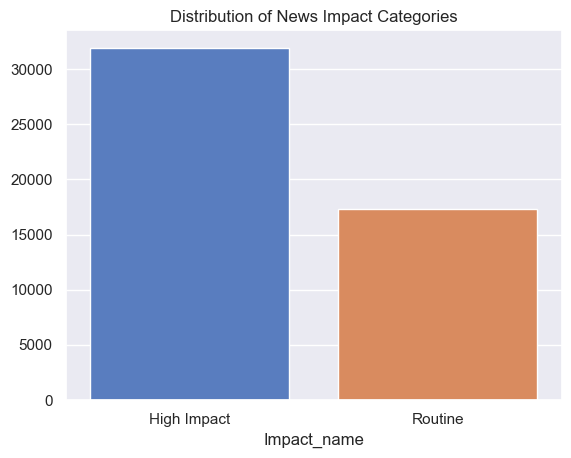

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme('notebook')

impact_name = dataset['Impact_name'].value_counts()
sns.barplot(x=impact_name.index, y=impact_name.values, hue=impact_name.index, palette='muted')
plt.title('Distribution of News Impact Categories')
plt.show()


### Topics distribution with most and least articles

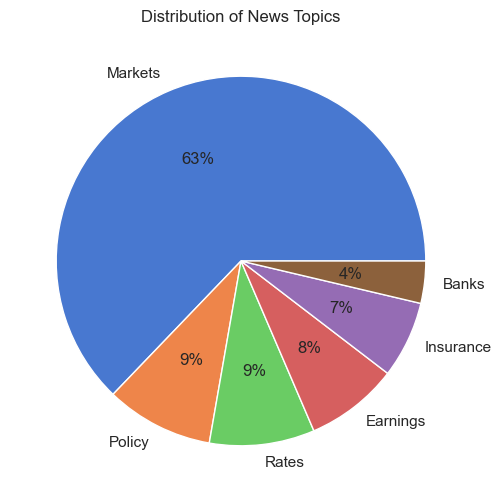

In [19]:
colors = sns.color_palette('muted')

topic_labels = dataset['Topic_Label'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(topic_labels, labels=topic_labels.index, colors=colors, autopct='%.0f%%')

plt.title('Distribution of News Topics')
plt.show()


### Topics distribution with News Impact

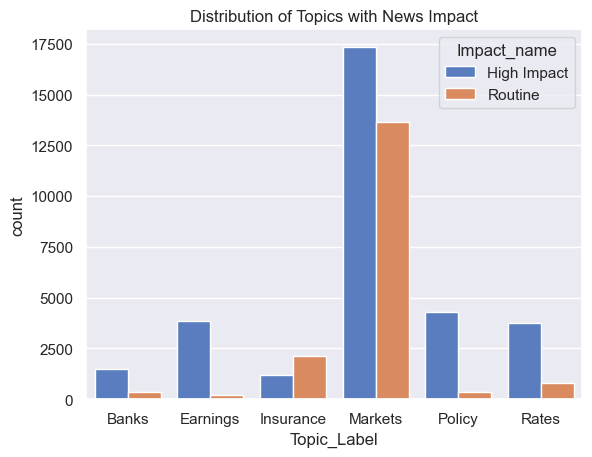

In [20]:
groupby_data = dataset.groupby('Topic_Label')['Impact_name'].value_counts().reset_index()

sns.barplot(x=groupby_data['Topic_Label'], y=groupby_data['count'], hue=groupby_data['Impact_name'], 
            palette='muted', legend=True, errorbar=None)
plt.title('Distribution of Topics with News Impact')
plt.show()


### Yearwise Topics trend

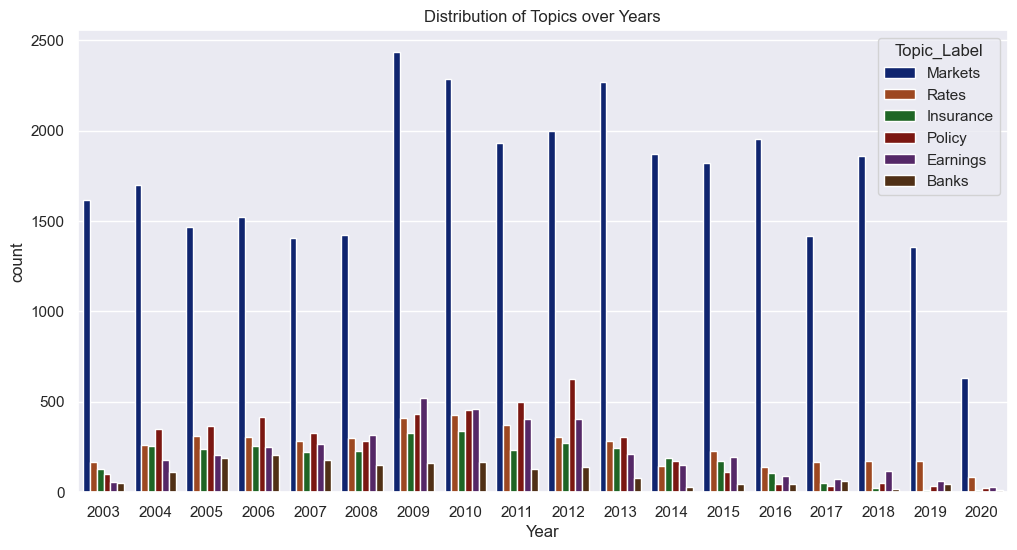

In [21]:
dataset['Date'] = pd.to_datetime(dataset['Date'], errors='coerce')
dataset['Year'] = dataset['Date'].dt.year

groupby_data = dataset.groupby('Year')['Topic_Label'].value_counts().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x=groupby_data['Year'], y=groupby_data['count'], hue=groupby_data['Topic_Label'], 
            palette='dark', legend=True, errorbar=None)

plt.title('Distribution of Topics over Years')
plt.show()


### Yearwise News Impact trend

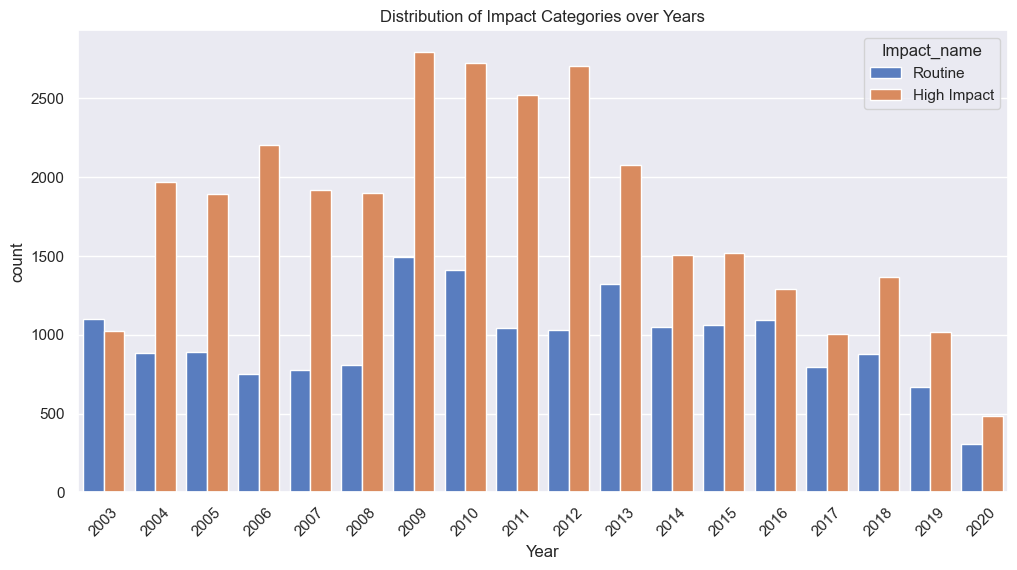

In [22]:
groupby_data = dataset.groupby('Year')['Impact_name'].value_counts().reset_index()

impact_name = groupby_data['Impact_name'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=groupby_data['Year'], y=groupby_data['count'], hue=groupby_data['Impact_name'], palette='muted')
plt.title('Distribution of Impact Categories over Years')
plt.xticks(rotation=45)
plt.show()


### Most Impactful Days of week

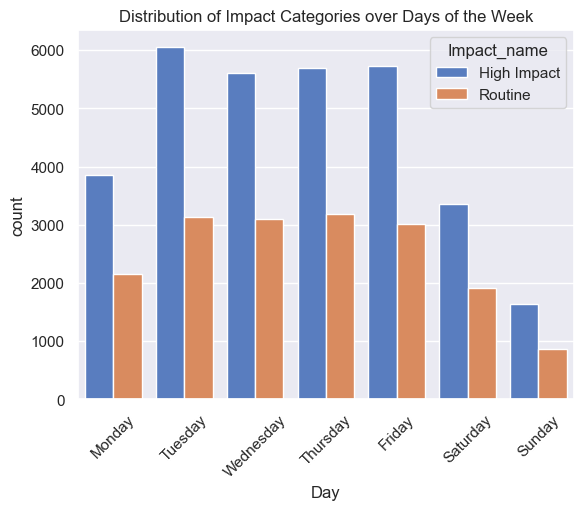

In [23]:
dataset['Day'] = dataset['Date'].dt.day_of_week
day_of_week_map = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}
groupby_data = dataset.groupby('Day')['Impact_name'].value_counts().reset_index()
groupby_data['Day'] = groupby_data['Day'].map(day_of_week_map)

sns.barplot(x=groupby_data['Day'], y=groupby_data['count'], hue=groupby_data['Impact_name'], palette='muted')
plt.title('Distribution of Impact Categories over Days of the Week')
plt.xticks(rotation=45)
plt.show()


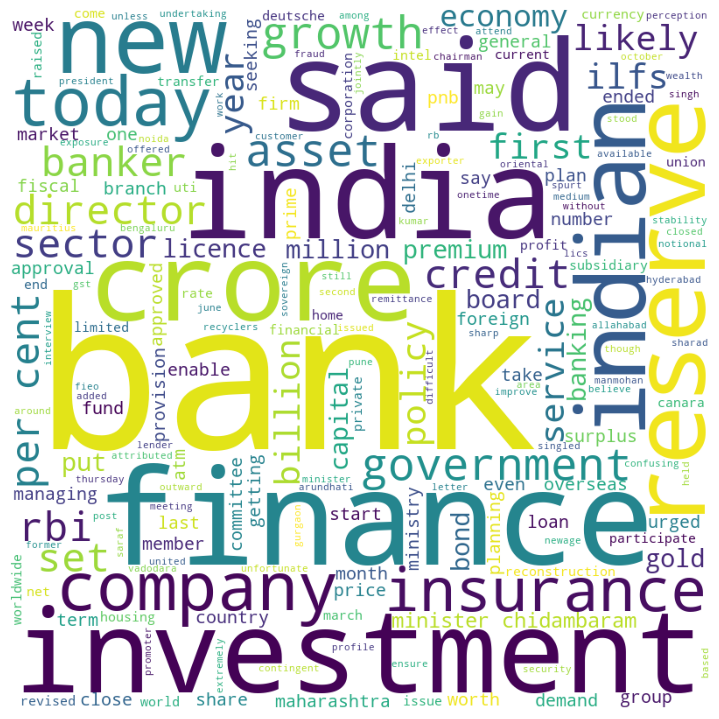

In [24]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

comment_words = []

dataset.index=range(dataset.shape[0])
for i in range(0, len(dataset), 750):
    comment_words.append(dataset['Cleaned_Desc'][i])
    vv=" ".join(comment_words)          
    wordcloud = WordCloud(width = 800, height = 800, 
                                background_color ='white', 
                                      min_font_size = 10).generate(vv)         
plt.figure(figsize = (9, 7), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.show() 

